# Outlier Filtering for Cool Dwarf Color-Temperature Relationships

This notebook implements outlier detection and filtering for the cross-matched Gaia-LAMOST-LAMOST_vac dataset.

**Approach Summary:**
- Use absolute magnitude colors (intrinsic stellar properties)
- 150 K Teff bins from 2800-4200 K
- 3σ clipping per bin
- Remove stars flagged as outliers in ≥2 different colors

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define paths using Path for cross-platform compatibility
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data')
NOTEBOOKS_DIR = Path('notebooks')
RESULTS_DIR = Path('results')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(exist_ok=True)

## Phase 1: Load and Inspect Dataset

Load the cross-matched dataset and verify its structure.

In [2]:
# Load the cross-matched dataset
input_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac.csv'
df = pd.read_csv(input_path)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
print("\nColumns:", df.columns.tolist())
print(f"\nTeff range: {df['teff'].min():.0f} - {df['teff'].max():.0f} K")
print(f"Teff mean: {df['teff'].mean():.0f} K, median: {df['teff'].median():.0f} K")

Dataset loaded: 48519 rows, 28 columns

Columns: ['obsid', 'subclass', 'gaia_source_id', 'Gmag', 'BPmag', 'RPmag', 'distance_gaia_pc', 'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', 'teff', 'logg', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_BAP', 'A_VAP', 'A_RAP', 'A_GSD', 'A_RSD', 'A_ISD']

Teff range: 3114 - 4138 K
Teff mean: 3690 K, median: 3724 K


In [3]:
# Basic data quality check
print("Missing values summary:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

# Filter to reasonable Teff range for cool dwarfs
teff_min, teff_max = 2800, 4200
df = df[(df['teff'] >= teff_min) & (df['teff'] <= teff_max)]
print(f"\nAfter Teff range filtering: {len(df)} stars")

Missing values summary:
Series([], dtype: int64)

After Teff range filtering: 48519 stars


## Phase 2: Create Color Indices

Create color indices from absolute magnitudes (A_*) for physics-based intrinsic properties.

In [4]:
# Define color combinations (absolute magnitudes)
color_combinations = {
    # Gaia EDR3 colors
    'A_GAIA_GBP_GRP': ('A_BP', 'A_RP'),
    'A_GAIA_G_GBP': ('A_GG', 'A_BP'),
    'A_GAIA_G_GRP': ('A_GG', 'A_RP'),
    
    # 2MASS NIR colors
    'A_2MASS_J_H': ('A_J', 'A_H'),
    'A_2MASS_H_KS': ('A_H', 'A_KS'),
    'A_2MASS_J_KS': ('A_J', 'A_KS'),
    
    # WISE NIR colors
    'A_WISE_W1_W2': ('A_W1', 'A_W2'),
    
    # SDSS optical colors
    'A_SDSS_G_R': ('A_GSD', 'A_RSD'),
    'A_SDSS_R_I': ('A_RSD', 'A_ISD'),
    'A_SDSS_G_I': ('A_GSD', 'A_ISD'),
    
    # APASS optical colors
    'A_APASS_B_V': ('A_BAP', 'A_VAP'),
    'A_APASS_V_R': ('A_VAP', 'A_RAP'),
}

# Create color columns
for color_name, (mag1, mag2) in color_combinations.items():
    df[color_name] = df[mag1] - df[mag2]

print(f"Created {len(color_combinations)} color indices")
print("Available colors:")
for name in color_combinations.keys():
    print(f"  {name}")

Created 12 color indices
Available colors:
  A_GAIA_GBP_GRP
  A_GAIA_G_GBP
  A_GAIA_G_GRP
  A_2MASS_J_H
  A_2MASS_H_KS
  A_2MASS_J_KS
  A_WISE_W1_W2
  A_SDSS_G_R
  A_SDSS_R_I
  A_SDSS_G_I
  A_APASS_B_V
  A_APASS_V_R


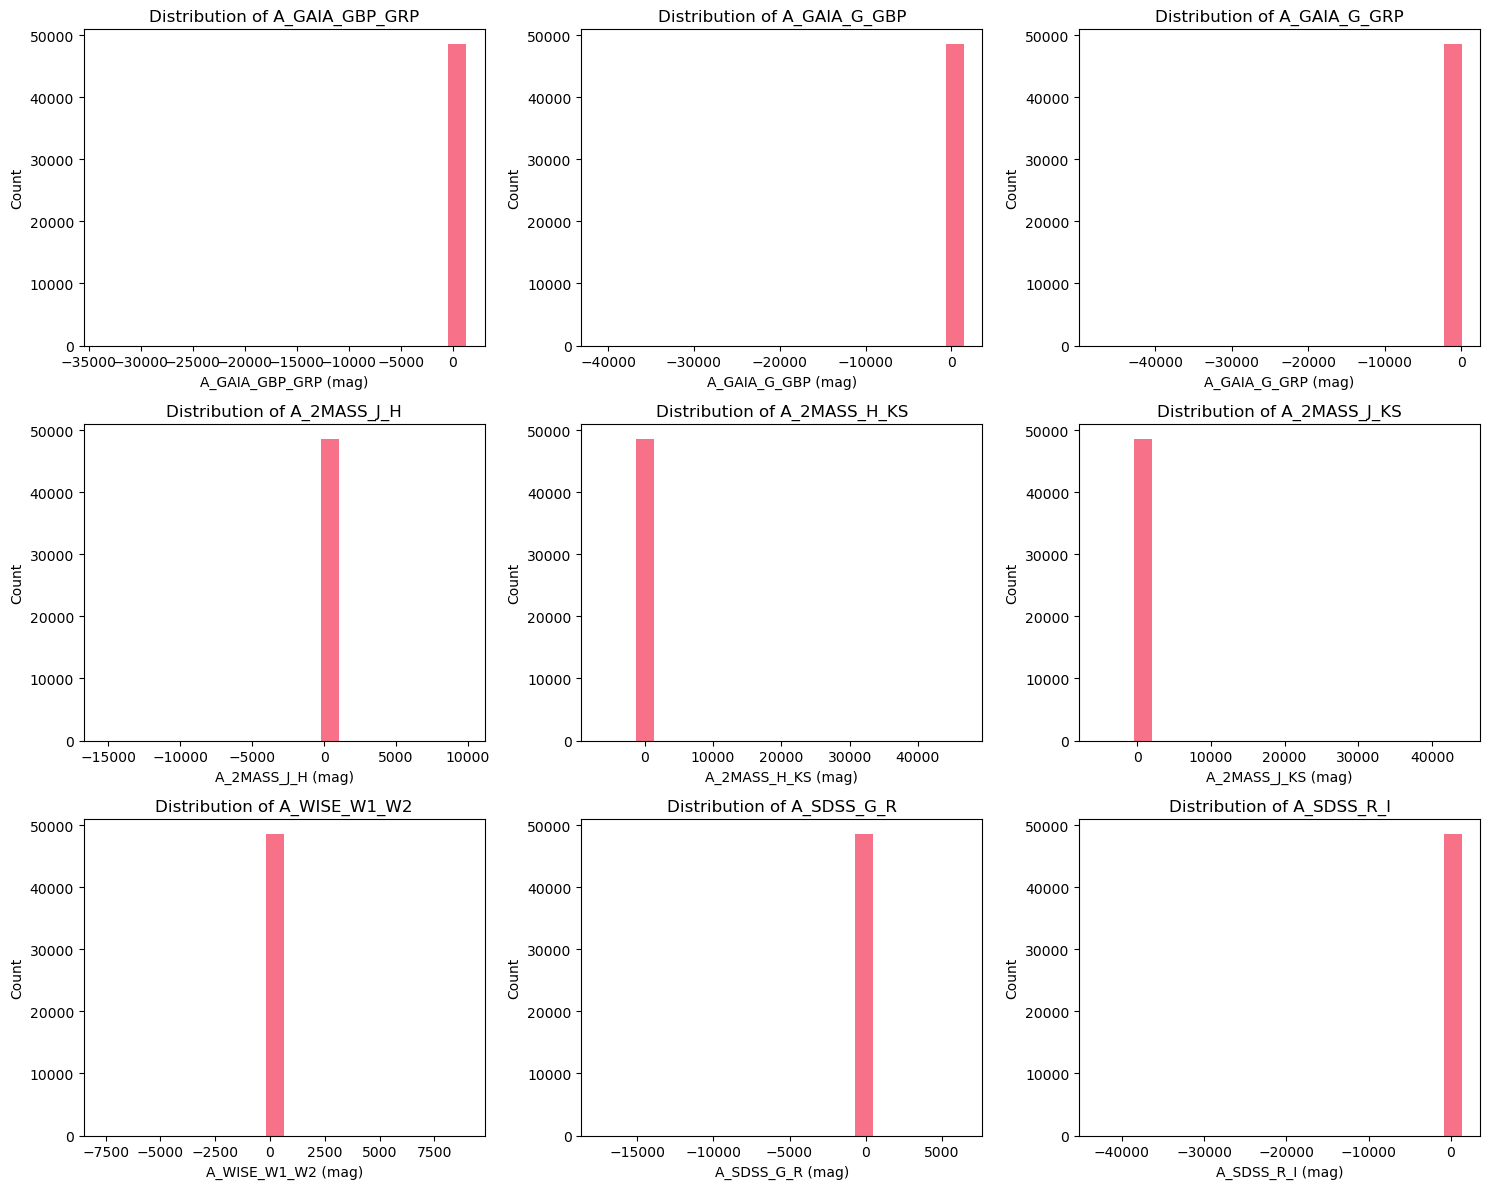

In [14]:
# Sanity check color distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, color_name in enumerate(list(color_combinations.keys())[:9]):
    if i < len(axes):
        ax = axes[i]
        df[color_name].plot.hist(bins=20, ax=ax)
        ax.set_xlabel(f'{color_name} (mag)')
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of {color_name}')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'color_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3: Teff Binning

Define Teff bins with fixed width (150 K) ensuring adequate samples per bin.

Teff bin statistics:
              teff                           
             count      min      max     mean
teff_bin                                     
3114-3264 K    934  3114.00  3263.95  3215.80
3264-3414 K   4732  3264.04  3413.98  3351.12
3414-3564 K   6818  3414.02  3563.99  3493.68
3564-3714 K  10710  3564.00  3713.99  3650.92
3714-3864 K  15313  3714.02  3863.99  3789.82
3864-4014 K   9830  3864.02  4013.94  3915.85
4014-4164 K    182  4014.11  4138.39  4043.46


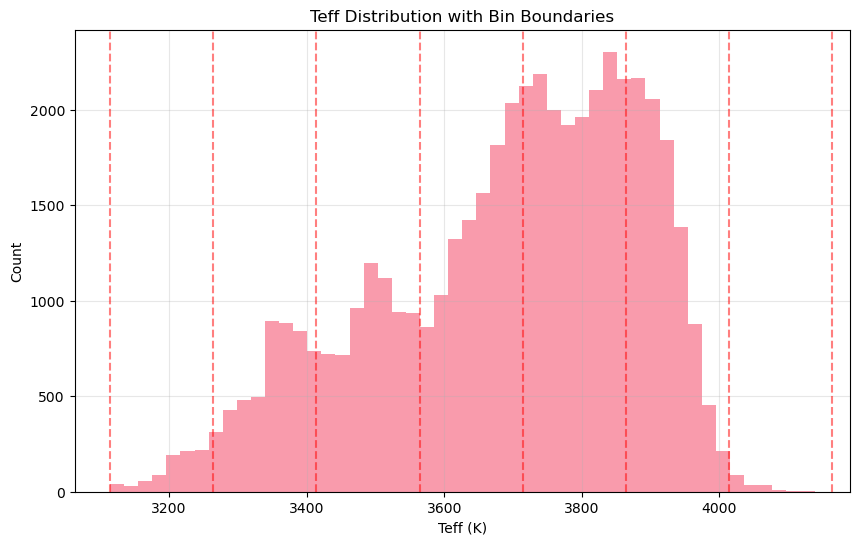

In [6]:
# Create Teff bins
bin_width = 150  # K
teff_bins = np.arange(3114, 4138 + bin_width, bin_width)

# Add bin column to dataframe
df['teff_bin'] = pd.cut(df['teff'], teff_bins, right=False, 
                        labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' 
                               for i in range(len(teff_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('teff_bin').agg({
    'teff': ['count', 'min', 'max', 'mean']
}).round(2)

print("Teff bin statistics:")
print(bin_stats)

# Visualize Teff distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['teff'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for teff_boundary in teff_bins:
    ax.axvline(teff_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('Teff (K)')
ax.set_ylabel('Count')
ax.set_title('Teff Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
plt.savefig(RESULTS_DIR / 'teff_distribution_bins.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4: Outlier Detection

Apply 3σ clipping per Teff bin for each color index.

In [ ]:
# Function to detect outliers in a given color for a given bin
def detect_outliers_3sigma(df_bin, color_name, sigma_threshold=3.0):
    # Return boolean mask where True indicates outlier
    values = df_bin[color_name].dropna()
    if len(values) < 10:  # Not enough data for meaningful statistics
        return pd.Series(False, index=df_bin.index)
    
    mean_val = values.mean()
    std_val = values.std()
    
    if std_val == 0:  # All values identical
        return pd.Series(False, index=df_bin.index)
    
    threshold = sigma_threshold * std_val
    outlier_mask = np.abs(df_bin[color_name] - mean_val) > threshold
    return outlier_mask

# Create outlier flags for each color and bin
outlier_columns = []

for color_name in color_combinations.keys():
    outlier_col_name = f'{color_name}_outlier'
    outlier_columns.append(outlier_col_name)
    df[outlier_col_name] = False  # Initialize as False
    
    # Process each bin separately
    for bin_name, df_bin in df.groupby('teff_bin'):
        outlier_mask = detect_outliers_3sigma(df_bin, color_name)
        df.loc[outlier_mask.index, outlier_col_name] = outlier_mask

print(f"Created {len(outlier_columns)} outlier flag columns")

Created 12 outlier flag columns


In [8]:
# Create consensus outlier flag: outlier if flagged in ≥2 colors
df['outlier_consensus'] = df[outlier_columns].sum(axis=1) >= 2

# Summary statistics
total_stars = len(df)
outlier_stars = df['outlier_consensus'].sum()
clean_stars = total_stars - outlier_stars

print(f"Total stars: {total_stars}")
print(f"Outliers (flagged in ≥2 colors): {outlier_stars} ({100*outlier_stars/total_stars:.1f}%)")
print(f"Clean stars: {clean_stars} ({100*clean_stars/total_stars:.1f}%)")

# Print survival statistics by bin
print("\nSurvival statistics by Teff bin:")
bin_survival = df.groupby('teff_bin').agg({
    'obsid': 'count',
    'outlier_consensus': 'sum'
})
bin_survival.columns = ['total', 'outliers']
bin_survival['survival_rate'] = 100 * (1 - bin_survival['outliers']/bin_survival['total'])
print(bin_survival.round(2))

Total stars: 48519
Outliers (flagged in ≥2 colors): 105 (0.2%)
Clean stars: 48414 (99.8%)

Survival statistics by Teff bin:
             total  outliers  survival_rate
teff_bin                                   
3114-3264 K    934         6          99.36
3264-3414 K   4732         2          99.96
3414-3564 K   6818         7          99.90
3564-3714 K  10710        17          99.84
3714-3864 K  15313        62          99.60
3864-4014 K   9830         9          99.91
4014-4164 K    182         2          98.90


## Phase 5: Diagnostic Plots

Generate color vs Teff plots showing outliers.

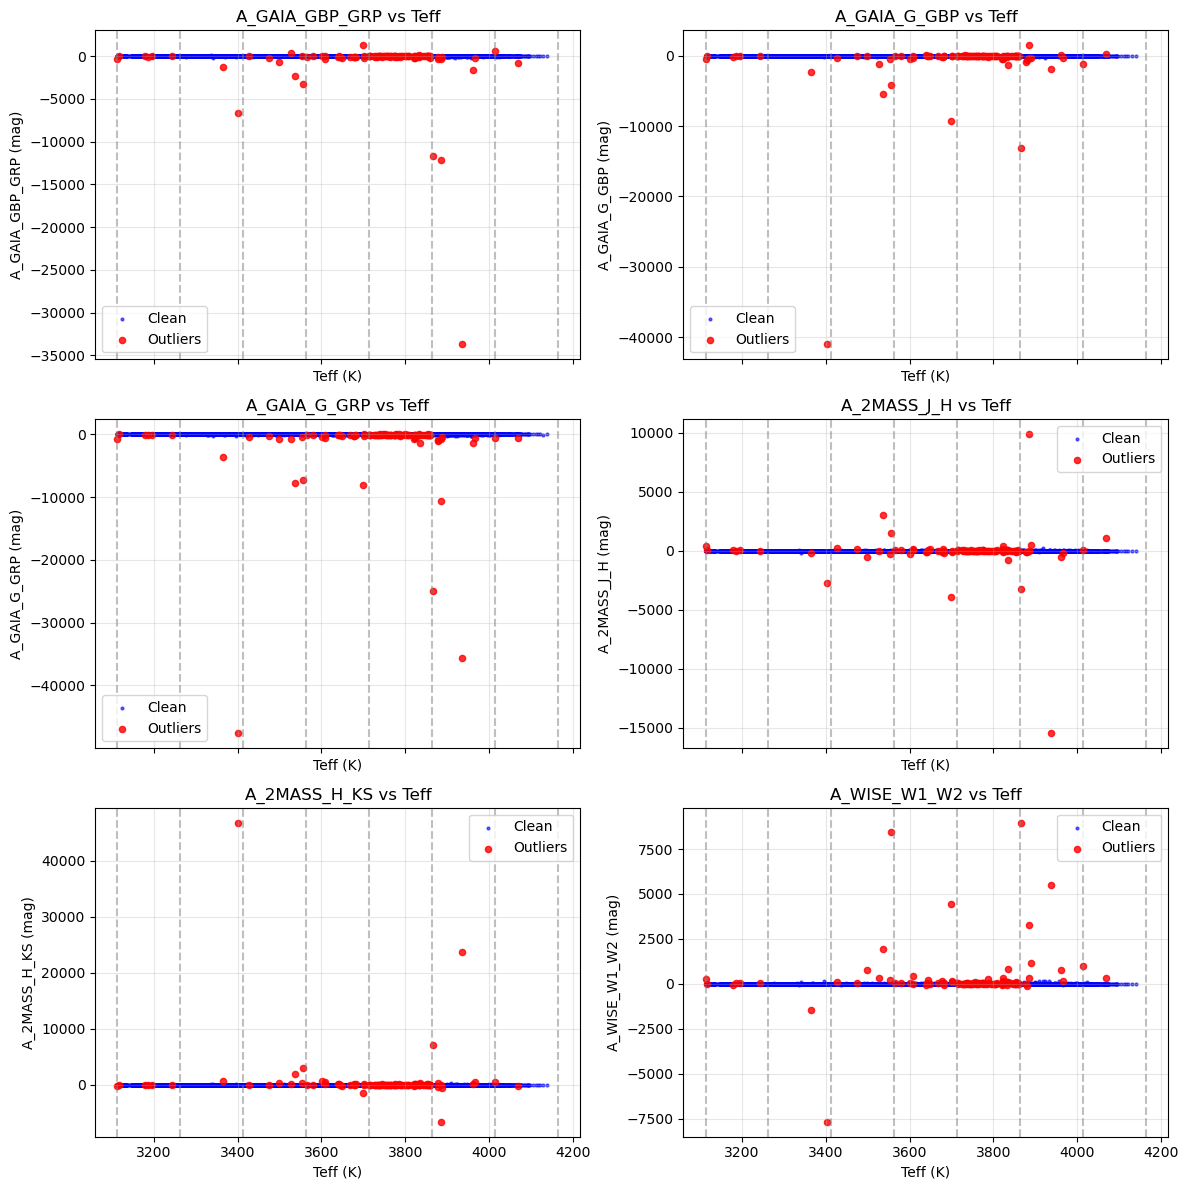

In [9]:
# Select top colors for visualization
top_colors = ['A_GAIA_GBP_GRP', 'A_GAIA_G_GBP', 'A_GAIA_G_GRP', 
              'A_2MASS_J_H', 'A_2MASS_H_KS', 'A_WISE_W1_W2']

# Create color vs Teff plots
n_cols = 2
n_rows = (len(top_colors) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows), sharex=True)
axes = axes.flatten() if n_rows > 1 else [axes]

for i, color_name in enumerate(top_colors):
    if i >= len(axes):
        break
    
    ax = axes[i]
    
    # Plot non-outliers
    mask = ~df['outlier_consensus']
    ax.scatter(df.loc[mask, 'teff'], df.loc[mask, color_name], 
               color='blue', alpha=0.6, s=4, label='Clean')
    
    # Plot outliers
    mask = df['outlier_consensus']
    ax.scatter(df.loc[mask, 'teff'], df.loc[mask, color_name], 
               color='red', alpha=0.8, s=20, label='Outliers')
    
    ax.set_xlabel('Teff (K)')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs Teff')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add bin boundaries
    for teff_boundary in teff_bins:
        ax.axvline(teff_boundary, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'color_vs_teff_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

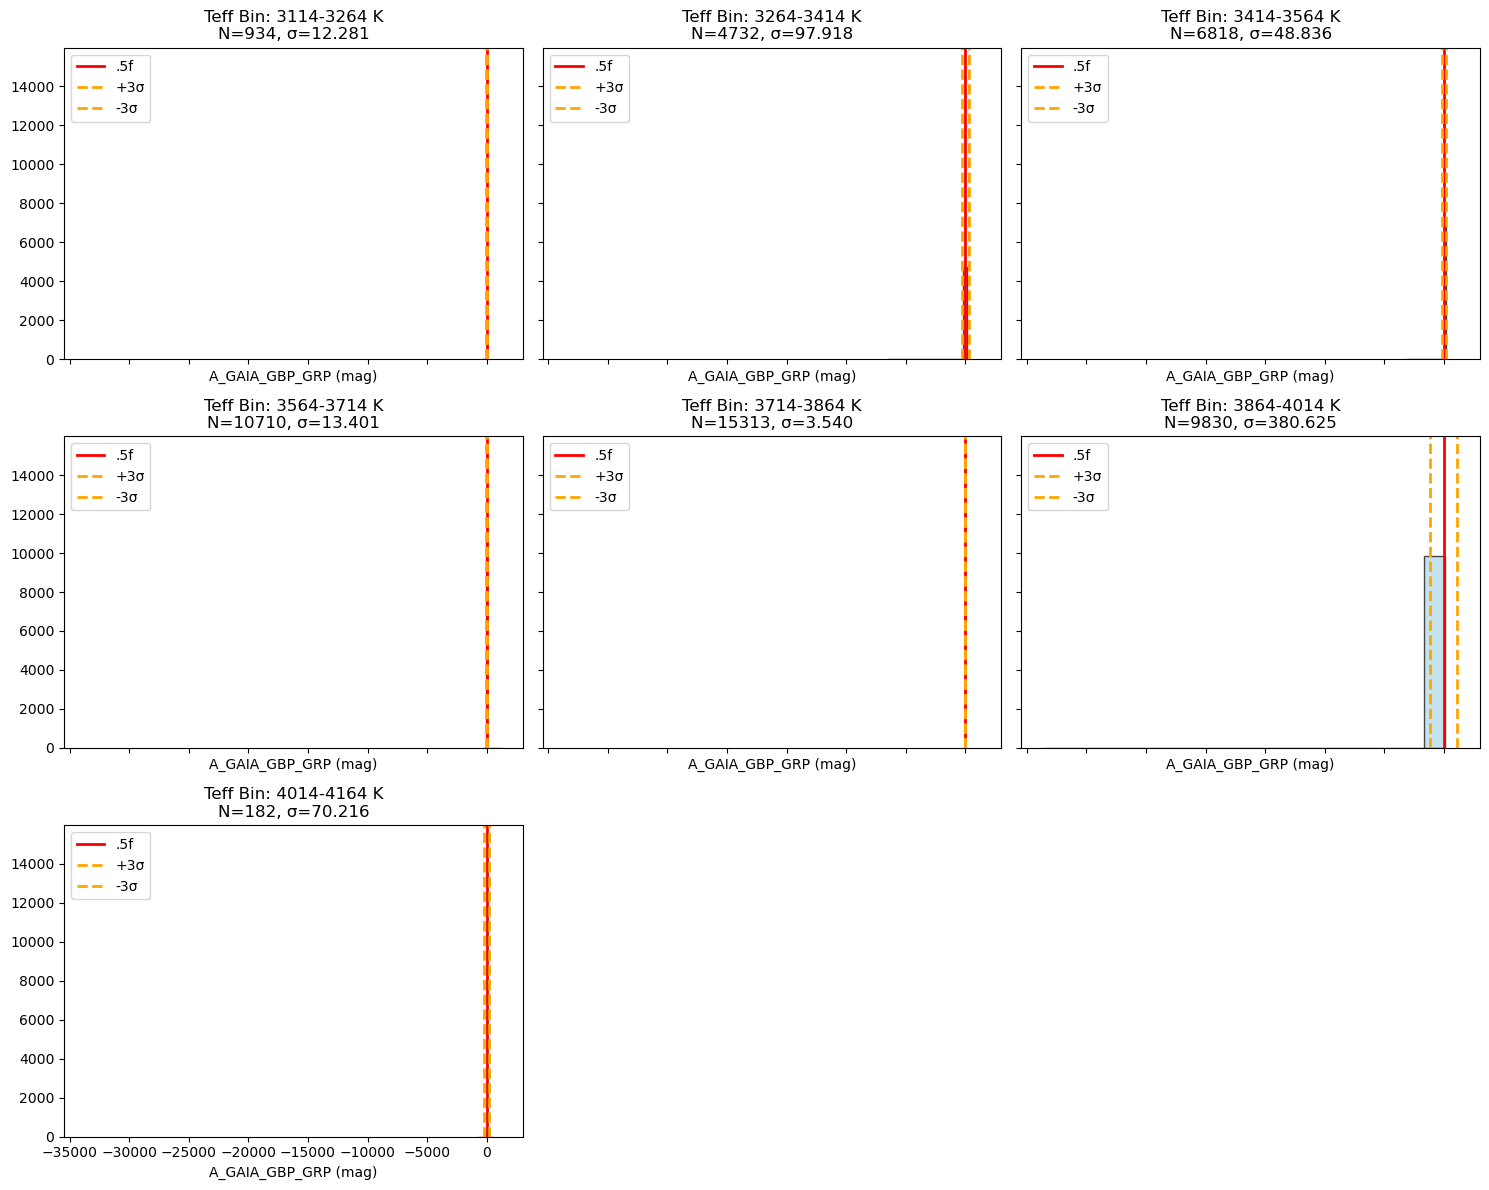

In [10]:
# Detailed bin-wise plots for top color
top_color = 'A_GAIA_GBP_GRP'
teff_bins_for_plot = df['teff_bin'].dropna().unique()

n_bins = len(teff_bins_for_plot)
n_cols = 3
n_rows = (n_bins + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, bin_name in enumerate(sorted(teff_bins_for_plot)):
    if i >= len(axes):
        break
    
    ax = axes[i]
    df_bin = df[df['teff_bin'] == bin_name]
    
    # Calculate statistics
    values = df_bin[top_color].dropna()
    if len(values) > 0:
        mean_val = values.mean()
        std_val = values.std()
        
        # Plot histogram
        ax.hist(values, bins=20, alpha=0.7, color='lightblue', edgecolor='black')
        
        # Add vertical lines for mean and 3σ thresholds
        ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label='.5f')
        ax.axvline(mean_val + 3*std_val, color='orange', linestyle='--', linewidth=2, label='+3σ')
        ax.axvline(mean_val - 3*std_val, color='orange', linestyle='--', linewidth=2, label='-3σ')
        
        ax.set_xlabel(f'{top_color} (mag)')
        ax.set_title(f'Teff Bin: {bin_name}\nN={len(values)}, σ={std_val:.3f}')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, ha='center')
        ax.set_title(f'Teff Bin: {bin_name}\nN=0')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'bin_distributions_top_color.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 6: Save Filtered Dataset

Create clean dataset and save both versions.

In [11]:
# Create clean and outlier datasets
df_clean = df[~df['outlier_consensus']].copy()
df_outliers = df[df['outlier_consensus']].copy()

# Remove temporary columns before saving
cols_to_drop = outlier_columns + ['teff_bin', 'outlier_consensus']
df_clean_out = df_clean.drop(columns=cols_to_drop, errors='ignore')
df_outliers_out = df_outliers.drop(columns=cols_to_drop, errors='ignore')

# Save datasets
clean_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_clean.csv'
outliers_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_outliers.csv'

df_clean_out.to_csv(clean_path, index=False)
df_outliers_out.to_csv(outliers_path, index=False)

print(f"Clean dataset saved: {len(df_clean_out)} stars -> {clean_path}")
print(f"Outliers dataset saved: {len(df_outliers_out)} stars -> {outliers_path}")

# Final summary
print("\n=== FINAL SUMMARY ===")
print(f"Original dataset: {len(df)} stars")
print(f"After Teff filtering: {len(df)} stars")
print(f"Final clean dataset: {len(df_clean_out)} stars")
print(f"Total outliers removed: {len(df_outliers_out)} stars")
print(f"Survival rate: {100*len(df_clean_out)/len(df):.1f}%")

Clean dataset saved: 48414 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_gaia_LAMOST_LAMOSTvac_clean.csv
Outliers dataset saved: 105 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_gaia_LAMOST_LAMOSTvac_outliers.csv

=== FINAL SUMMARY ===
Original dataset: 48519 stars
After Teff filtering: 48519 stars
Final clean dataset: 48414 stars
Total outliers removed: 105 stars
Survival rate: 99.8%
